# Grid cells on the torus

The 2D analogue of the ring analysis: rate maps sampled from a Gaussian process on the
torus, their gridness statistics, and the toroidal attractor built from them.

**Produces** Figure 8 (`figures/grid_cell_simulations.pdf`) and Supplementary Figure S15
(`figures/grid_cell_eigenvalues.pdf`).

**Reads** `data/grid_analysis_results.npz`, `data/eta_analysis.npz`,
`data/gridness_hist_digitized.npz`, `data/experimental_gridness_scores.npy` and the
published rate-map images under `figures/external/`.

## Setup: torus correlation function, GP sampling, and gridness scoring

Defines the whole machinery in one cell: `make_Gamma_x` builds the correlation function on the hexagonal torus (the parameter `η` interpolates between a single large-period field, `η→0`, and a fully periodic grid, `η=1`); `sample_2d_gp` draws rate maps with that correlation; `compute_gridness` reproduces the standard rotational-autocorrelation gridness score at 60°/120° vs. 30°/90°/150°. `np.random.seed(42)` at the top pins both the GP noise and the initial-condition noise. The seed is set once, here, so later cells draw from one random stream in order: a clean top-to-bottom run is reproducible, while running cells out of order is not.

In [1]:
# Regeneration switches (default off so a normal run cannot overwrite committed figures/caches):
REGENERATE_CACHES = False
SAVE_FIGURES = False

import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from tqdm import tqdm
from itertools import product
from scipy.ndimage import rotate
from scipy.stats import pearsonr
from ring import sim, fn, data_driven, style
device = 'cuda' if torch.cuda.is_available() else 'cpu'

np.random.seed(42)

M = np.array([[1., 0.5], [0., np.sqrt(3.)/2]]) / (2*np.pi)

"""
For comp to paper I believe: sigma = sqrt(2)/radius!
"""

def nonlin_idealized(x, g=2.5):
    return 1 + fn.unity_erf(g*x)

def make_Gamma_x(N_phi, N_period, radius, eta, eq_var=1.):
    """Generate the correlation function on the torus"""
    B = (1/(eta+1e-20)) - 1
    
    # Define field centers (fine spacing)
    num_reps = 10
    field_phi = np.arange(-num_reps*N_period, (num_reps+1)*N_period)*2*np.pi
    field_locations_phi_12 = np.array(list(product(field_phi, field_phi)))
    field_locations_xy = field_locations_phi_12 @ M.T

    # Define extra field centers (big spacing)
    extra_field_phi = np.arange(-num_reps, num_reps+1)*N_period*2*np.pi
    extra_field_locations_phi_12 = np.array(list(product(extra_field_phi, extra_field_phi)))
    extra_field_locations_xy = extra_field_locations_phi_12 @ M.T

    def eval_grid(eval_phi_12):
        eval_phi_12 = np.mod(eval_phi_12, N_period*2*np.pi)
        eval_xy = eval_phi_12 @ M.T
        result = np.zeros(eval_phi_12.shape[:-1])
        for i, field_loc_xy in enumerate(np.concatenate((extra_field_locations_xy, field_locations_xy), axis=0)):
            factor = B if i < len(extra_field_locations_xy) else 1.
            dists = np.sqrt(np.sum((eval_xy - field_loc_xy)**2, -1))
            result += factor*np.exp(-(dists/radius)**2)
        return result / (1+B)

    phi = np.arange(N_phi)*N_period*2*np.pi/N_phi
    phi_1, phi_2 = np.meshgrid(phi, phi)
    phi_12 = np.array((phi_1.T, phi_2.T)).T
    Gamma_x = eval_grid(phi_12)
    return phi_12, Gamma_x

def sample_2d_gp(Gamma_x, N_samples=1):
    """Sample from 2D Gaussian Process"""
    Gamma_x_ft = np.fft.fft2(Gamma_x, norm='forward')
    N_freq = Gamma_x_ft.shape[0]
    
    Gamma_x_ft = np.clip(Gamma_x_ft.real, a_min=0., a_max=None)
    noise = (np.random.randn(N_samples, N_freq, N_freq) + 
             1j*np.random.randn(N_samples, N_freq, N_freq))
    noise = np.fft.fft2(np.fft.ifft2(noise).real)
    
    A_ft = np.sqrt(Gamma_x_ft) * noise
    A = np.fft.ifft2(A_ft, norm='forward').real
    A_corr = np.fft.ifft2(np.abs(np.fft.fft2(A))**2, norm='forward').real
    N_phi = A.shape[-1]
    A_corr = np.roll(A_corr, shift=-N_phi//2, axis=(1,2))
    
    return A, A_corr

def create_cartesian_image(x, y, A, dx, fill_nan=True):
    """Create 2D image from scattered data points"""
    if not (x.shape == y.shape == A.shape):
        raise ValueError("x, y, and A must have the same shape")
    
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    nx = int(np.ceil((x_max - x_min) / dx))
    ny = int(np.ceil((y_max - y_min) / dx))
    
    pixel_x = ((x - x_min) / dx).astype(int).ravel()
    pixel_y = ((y - y_min) / dx).astype(int).ravel()
    
    image, _, _ = np.histogram2d(
        pixel_y, pixel_x, 
        bins=(ny, nx), 
        range=((0, ny), (0, nx)), 
        weights=A.ravel()
    )
    
    counts, _, _ = np.histogram2d(
        pixel_y, pixel_x, 
        bins=(ny, nx), 
        range=((0, ny), (0, nx))
    )
    
    if fill_nan:
        image[counts == 0] = np.nan
    counts[counts == 0] = 1
    image = image / counts
    return image

def analyze_image_rotations(im, num_rotations=50, plot=False):
    """Analyze image rotations and compute correlations"""
    center_y, center_x = np.array(im.shape) // 2
    y, x = np.ogrid[:im.shape[0], :im.shape[1]]
    distances = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    
    R = min(im.shape) / 3.5
    annulus = (distances >= 0.5*R) & (distances <= 1.5*R)
    masked_im = im.copy()
    masked_im[~annulus] = np.nan
    
    if plot:
        plt.imshow(masked_im, origin='lower', aspect=1.)
        plt.show()
    
    def nanpearsonr(a, b):
        mask = ~(np.isnan(a) | np.isnan(b))
        if np.sum(mask) < 2:
            return np.nan
        return pearsonr(a[mask], b[mask])[0]
    
    angles = np.linspace(0, 180, num_rotations, endpoint=False)
    correlations = []
    
    for angle in angles:
        rotated = rotate(masked_im, angle, reshape=False, order=1, mode='constant', cval=np.nan)
        corr = nanpearsonr(masked_im.ravel(), rotated.ravel())
        correlations.append(corr)
    
    return angles, np.array(correlations)

def compute_gridness(A_corr_im, plot=False):
    """Compute gridness score from autocorrelation image"""
    angles, corrs = analyze_image_rotations(A_corr_im, plot=plot)
    
    if plot:
        plt.plot(angles, corrs)
        for theta in (30, 60, 90, 120, 150):
            plt.axvline(theta)
        plt.show()
        
    idx_vals = np.array([np.argmin((angles - th)**2) for th in (60, 120, 30, 90, 150)])
    on_idx = idx_vals[:2]
    off_idx = idx_vals[2:]
    gridness = np.min(corrs[on_idx]) - np.max(corrs[off_idx])
    return gridness

def generate_sample_data(N_samples, N_period, radius, eta, N_phi):
    """Generate sample data (returned in memory; nothing on disk reads it)."""
    phi_12, Gamma_x = make_Gamma_x(N_period=N_period, radius=radius, eta=eta, N_phi=N_phi)
    xy = phi_12 @ M.T
    A, A_corr = sample_2d_gp(Gamma_x, N_samples=N_samples)
    
    X = A.reshape(len(A), -1).T.copy()
    X -= X.mean(0)
    X /= X.std(0)
    return X, phi_12, xy, Gamma_x

def compute_weights_and_trajectories(X, phi_12, noise_std, T, tau, T_eval, dt=None):
    """Compute weights and simulate trajectories"""
    if dt is None:
        dt = tau / 10.
        
    # Compute weights
    Phi = nonlin_idealized(X)
    J, J_prime = data_driven.compute_weights(X, Phi, lamda=1e-8)

    err = np.sqrt(np.mean((X - (Phi @ J.T))**2))
    print("err =", err)

    # Initialize and simulate
    x_init_noiseless = X[::11].copy().T
    x_init = x_init_noiseless + np.random.randn(*x_init_noiseless.shape) * noise_std
    
    _, x_save, _ = sim.run_sim(
        T=T, tau=tau, dt=dt, T_eval=T_eval,
        J=torch.Tensor(J).to(device),
        x_init=torch.Tensor(x_init).to(device),
        nonlin=nonlin_idealized
    )
    
    # Compute phi values in chunks
    chunk_size = 5
    phi_save = np.zeros_like(x_save)
    for i in tqdm(range(0, len(x_save), chunk_size)):
        chunk = torch.from_numpy(x_save[i:i+chunk_size]).to(device)
        phi_save[i:i+chunk_size] = nonlin_idealized(chunk).cpu().numpy()
    
    Phi = nonlin_idealized(X)
    # SIX components, not three. The leading PCA block here is six-fold
    # near-degenerate (three lattice directions x cos/sin), the six eigenvalues
    # spanning under 5% with a 92% gap to the seventh, so which three come out on
    # top is decided by noise and the resulting 3D view is unstable. Keep the whole
    # block and pick the display axes deterministically from the known toroidal
    # phases instead; see data_driven.torus_display_frame.
    pcs, pcs_traj = data_driven.do_pca_on_tcs_and_trajectories(Phi, phi_save, N_pcs=6)
    frame = data_driven.torus_display_frame(
        pcs, phase_a=phi_12[..., 0].ravel(), phase_b=phi_12[..., 1].ravel())
    pcs_display = pcs @ frame.T
    pcs_traj_display = np.einsum('tkb,mk->tmb', pcs_traj, frame, optimize='optimal')
    
    np.savez('../data/grid_analysis_results.npz', #J=J, x_save=x_save, phi_save=phi_save, 
             pcs=pcs, pcs_traj=pcs_traj,
             pcs_display=pcs_display, pcs_traj_display=pcs_traj_display,
             display_frame=frame)
    return pcs, pcs_traj

def plot_3d_torus(ax=None, data_path='../data/grid_analysis_results.npz'):
    """Plot 3D torus visualization"""
    if ax is None:
        fig = plt.figure(figsize=(4, 4))
        ax = fig.add_subplot(projection='3d')
    
    data = np.load(data_path)
    # The coloured trajectories are the point of this panel, so keep the torus
    # cloud light and the black end/start markers small: at the defaults the
    # dense grey cloud and the markers swamped the trajectory colours.
    # Plot in the torus display frame, not the raw top-3 PCs; see the note in
    # compute_weights_and_trajectories and data_driven.torus_display_frame.
    data_driven.plot_3d_pca(ax, data['pcs_display'], data['pcs_traj_display'], torus=True,
                            cloud_color='0.55', cloud_alpha=0.09, cloud_s=7,
                            traj_lw=1.1, end_s=6, start_s=3.5)
    # The axes are orthonormal combinations of the six degenerate PCs, chosen so that
    # the first toroidal phase sweeps a circle in the x-y plane, so they are not PC 1,
    # 2, 3 and are not labelled as such.
    ax.set_xlabel("torus 1", labelpad=-16, rotation=65)
    ax.set_ylabel("torus 2", labelpad=-16, rotation=-9.25)
    ax.set_zlabel("torus 3", labelpad=-18, rotation=92)
    # Look partly DOWN the tube axis. In the display frame the second toroidal phase
    # runs along z, so the manifold is a circle swept along z and a side-on camera
    # renders it as a barrel with no visible hole. elev=55 is high enough that the
    # hole through the middle is unmistakable while the near and far walls still read
    # as a 3D object.
    ax.view_init(elev=55, azim=20)
    return ax


## Generate sample data and simulate (writes `grid_analysis_results.npz`)

`do_analyses()` samples 25,000 rate maps, fits `J` against them, integrates the network from perturbed initial conditions, and saves `../data/grid_analysis_results.npz`. The call only runs when `REGENERATE_CACHES = True`: the cache is what Fig 8 is drawn from, it needs a GPU and substantial time to rebuild, and a rebuild would overwrite your download.

In [2]:
import numpy as np
import torch
from pathlib import Path

def do_analyses():
    print("Generating sample data...")
    X, phi_12, xy, Gamma_x = generate_sample_data(N_samples=25000, radius=0.35, N_phi=50, eta=1., N_period=1)
    
    print("Computing weights and trajectories...")
    pcs, pcs_traj = compute_weights_and_trajectories(X=X, phi_12=phi_12, noise_std=0.5, T=30, T_eval=0.1, tau=0.05)
    
    print("Data generation complete. Files saved in data/")

if REGENERATE_CACHES:
    do_analyses()


## Check: trajectories fill a torus in PC space

Quick 3D view of the cached PCA; the tuning-curve manifold and the relaxed trajectories should both lie on a torus. The same plot appears as the right-hand panel of Fig 8.

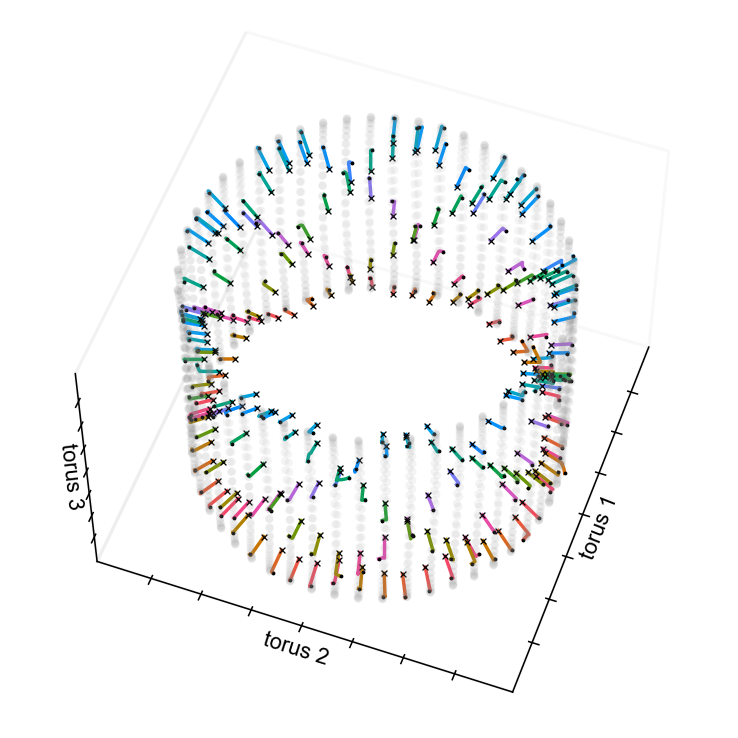

In [3]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(projection='3d')
plot_3d_torus(ax)
plt.show()

## Gridness as a function of `η` (writes `eta_analysis.npz`)

`analyze_eta_range` sweeps `η ∈ {0.2 … 1.0}`, scores 1,000 samples at each, and saves the score distributions plus five representative rate maps per `η` to `../data/eta_analysis.npz`. The call at the bottom only runs when `REGENERATE_CACHES = True` for the same reason as the cell above. `plot_patterns_subplot` reads the cache back and is called by the figure cell below.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

def get_evenly_spaced_range_indices(x, n):
    if n < 2:
        raise ValueError("n must be at least 2")
    min_val = np.percentile(x, 2.5)
    max_val = np.percentile(x, 97.5)
    target_values = np.linspace(min_val, max_val, n)
    indices = np.array([np.abs(x - target_value).argmin() for target_value in target_values])
    return indices

def analyze_eta_range(save_path, N_visualize=5):
    params = {
        'N_phi': 80, 'radius': 0.35, 'N_period': 3,
        'N_samples': 1000, 'N_vis_samples': N_visualize,
        'eta_values': np.array([0.2, 0.4, 0.6, 0.8, 1.0])
    }
    
    n_etas = len(params['eta_values'])
    gridness_scores = np.zeros((n_etas, params['N_samples']))
    vis_samples = np.zeros((n_etas, N_visualize, params['N_phi'], params['N_phi']))
    vis_samples_corr = np.zeros((n_etas, N_visualize, params['N_phi'], params['N_phi']))  # Added this line
    vis_scores = np.zeros((n_etas, N_visualize))
    vis_indices = np.zeros((n_etas, N_visualize), dtype=int)
    
    for eta_idx, eta in enumerate(params['eta_values']):
        phi_12, Gamma_x = make_Gamma_x(eta=eta, **{k: params[k] for k in ['N_phi', 'radius', 'N_period']})
        if eta_idx == 0:
            xy = phi_12 @ M.T
            
        A, A_corr = sample_2d_gp(Gamma_x, N_samples=params['N_samples'])
        
        # Normalize patterns and compute scores
        A = (A - A.mean((1,2), keepdims=True)) / A.std((1,2), keepdims=True)
        A_corr = (A_corr - A_corr.mean((1,2), keepdims=True)) / A_corr.std((1,2), keepdims=True)
        
        for i in tqdm(range(params['N_samples']), desc=f'η={eta:.2f}'):
            gridness_scores[eta_idx, i] = compute_gridness(
                create_cartesian_image(x=xy[...,0], y=xy[...,1], dx=0.1, A=A_corr[i]))
        
        # Select uniformly spaced samples
        selected_idx = get_evenly_spaced_range_indices(gridness_scores[eta_idx], N_visualize)
        vis_indices[eta_idx] = selected_idx
        vis_samples[eta_idx] = A[selected_idx]
        vis_samples_corr[eta_idx] = A_corr[selected_idx]  # Added this line
        vis_scores[eta_idx] = gridness_scores[eta_idx, selected_idx]
    
    np.savez(save_path, xy=xy, params=np.array([params]), **{
        'eta_values': params['eta_values'],
        'gridness_scores': gridness_scores,
        'vis_samples': vis_samples,
        'vis_samples_corr': vis_samples_corr,  # Added this line
        'vis_scores': vis_scores,
        'vis_indices': vis_indices
    })


import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ring import data_driven

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from ring import data_driven


def plot_patterns_subplot(hist_axes, pattern_axes, corr_axes, data_path='../data/eta_analysis.npz', eta_idx=2, hist_color=style.DATA):
    """Plot gridness distributions and patterns on provided axes"""
    data = np.load(data_path, allow_pickle=True)
    
    # Plot histograms
    hist_range = (-2, 2)
    bins = 20
    
    for i, (ax, eta) in enumerate(zip(hist_axes, data['eta_values'])):
        ax.hist(data['gridness_scores'][i], density=True, alpha=1,
               color=hist_color, range=hist_range, bins=bins)
        ax.set_xlim(hist_range)
        ax.set_ylim(0, 2)
        ax.set_title(f'$\\eta={eta:.1f}$')
        
        ax.set_xlabel('grid score')
        if i > 0:
            ax.set_yticks([])
        else:
            ax.set_ylabel('density')
    
    # Plot samples and their autocorrelations
    def draw_rhombus_frame(ax, image):
        """Fit and draw the four straight edges of the finite-data rhombus."""
        valid = np.isfinite(image)
        rows = np.flatnonzero(valid.any(axis=1))
        left = np.argmax(valid[rows], axis=1)
        right = image.shape[1] - 1 - np.argmax(valid[rows, ::-1], axis=1)
        left_edge = np.polyfit(rows, left, 1)
        right_edge = np.polyfit(rows, right, 1)
        y0, y1 = rows[0] - 0.5, rows[-1] + 0.5
        vertices = [(np.polyval(left_edge, y0) - 0.5, y0),
                    (np.polyval(right_edge, y0) + 0.5, y0),
                    (np.polyval(right_edge, y1) + 0.5, y1),
                    (np.polyval(left_edge, y1) - 0.5, y1)]
        ax.add_patch(plt.Polygon(vertices, closed=True, fill=False,
                                 edgecolor='black', linewidth=0.4,
                                 joinstyle='miter', clip_on=False, zorder=5))

    x, y = data['xy'][..., 0], data['xy'][..., 1]
    
    for j, (pattern_ax, corr_ax, score) in enumerate(zip(
            pattern_axes, corr_axes, data['vis_scores'][eta_idx])):
        
        # Plot original pattern. The generative process is sign-symmetric, so a
        # sampled map is equally likely to show its hexagonal lattice as peaks
        # or as troughs; only the peaked ones become grid cells once passed
        # through a rectifying nonlinearity, so each map is shown that way up.
        # Nothing quantitative changes: the autocorrelation is |FFT|^2, which is
        # invariant under A -> -A, so the grid score and panel E are identical
        # either way. The maps carry zero mean and unit variance, so the mean
        # cube is exactly the skewness.
        sample = data['vis_samples'][eta_idx, j]
        if (sample ** 3).mean() < 0:
            sample = -sample
        img = create_cartesian_image(x, y, sample, dx=0.05)
        pattern_ax.imshow(img, cmap=style.GRID_CELL_CMAP, origin='lower', vmin=-2, vmax=2, interpolation='None')
        draw_rhombus_frame(pattern_ax, img)
        pattern_ax.set_title(f'grid score: ${score:.2f}$')
        
        # Plot autocorrelation
        img_corr = create_cartesian_image(x, y, data['vis_samples_corr'][eta_idx, j], dx=0.05)
        corr_ax.imshow(img_corr, cmap=style.GRID_CELL_CMAP, origin='lower', vmin=-2, vmax=2, interpolation='None')
        draw_rhombus_frame(corr_ax, img_corr)
        
        for ax in (pattern_ax, corr_ax):
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect(1.)
            ax.spines['left'].set_visible(False)
            ax.spines['bottom'].set_visible(False)

        if j == 0:
            pattern_ax.set_ylabel("input current", rotation=60)
            corr_ax.set_ylabel("autocorr.", rotation=60)
    
    # Add arrows
    target_ax = hist_axes[eta_idx]
    for score in data['vis_scores'][eta_idx]:
        target_ax.annotate('', xy=(score, 1.3), xytext=(score, 1.95),
                          arrowprops=dict(facecolor='black', shrink=0.0,
                                        width=1, headwidth=4, headlength=5))



if REGENERATE_CACHES:
    analyze_eta_range(save_path='../data/eta_analysis.npz', N_visualize=5)





## Gridness distributions, example maps, and the torus

Draws the `η` histograms, example rate maps with their autocorrelations, and the 3D PCA torus. This content is stable up to the seeded RNG. The compose cell below assembles the full `grid_cell_simulations` figure and adds the panel labels, so none are drawn here.

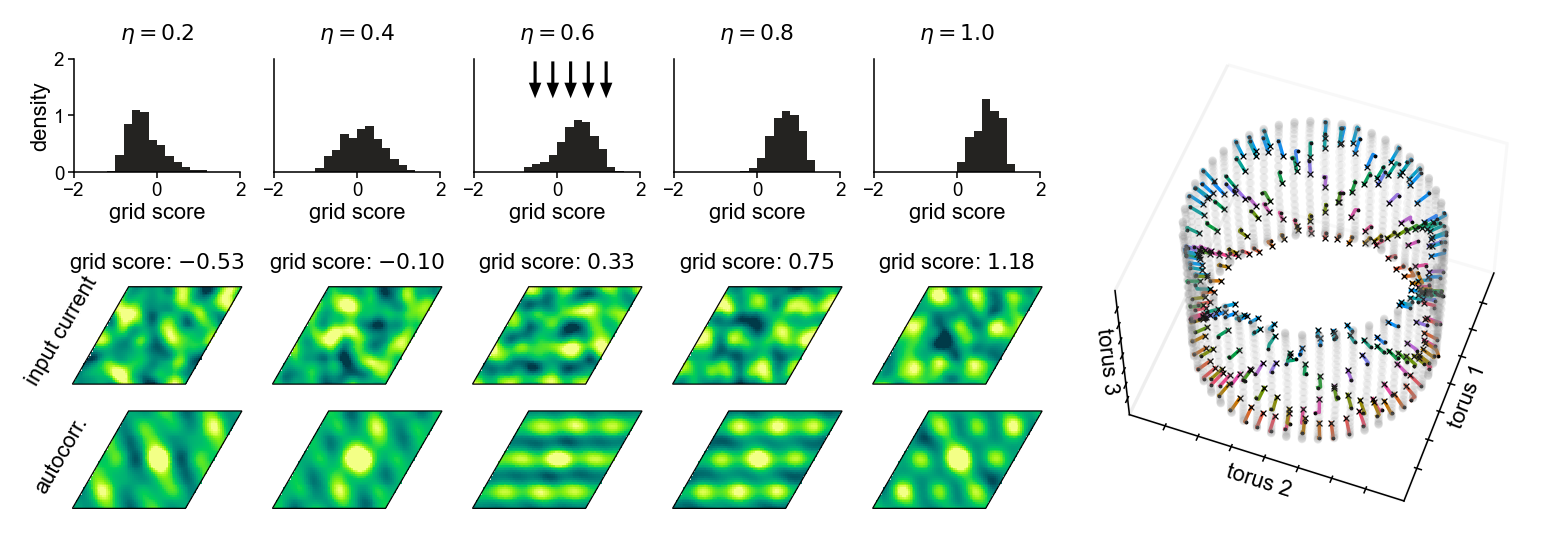

In [5]:
def create_composite_figure():
    """Create and save the complete composite figure"""
    fig = plt.figure(figsize=(7, 2.2))
    
    # Create main GridSpec - swapped width ratios from [2, 1] to [1, 2]
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.8, 1], wspace=0.0, left=0.045, right=1, top=0.925, bottom=0)
    
    # Right subplot - 3D PCA (moved from left)
    ax_3d = fig.add_subplot(gs[0, 1], projection='3d')
    plot_3d_torus(ax_3d)
    
    # Create nested GridSpec for left side (moved from right)
    gs_left = gridspec.GridSpecFromSubplotSpec(4, 5, subplot_spec=gs[0, 0],
                                              height_ratios=[1, 0.75, 1, 1],
                                              hspace=0.1)
    
    # Create all axes
    hist_axes = [fig.add_subplot(gs_left[0, i]) for i in range(5)]
    pattern_axes = [fig.add_subplot(gs_left[2, i]) for i in range(5)]
    corr_axes = [fig.add_subplot(gs_left[3, i]) for i in range(5)]
    
    # Plot patterns
    plot_patterns_subplot(hist_axes, pattern_axes, corr_axes)
    
    # Common label parameters
    label_params = {
        'va': 'top',
        'ha': 'left',
        'fontweight': 'bold',
        'fontsize': 10
    }
    
    # # Add subplot labels
    
    return fig

# Generate and save the figure
fig = create_composite_figure()
plt.show()


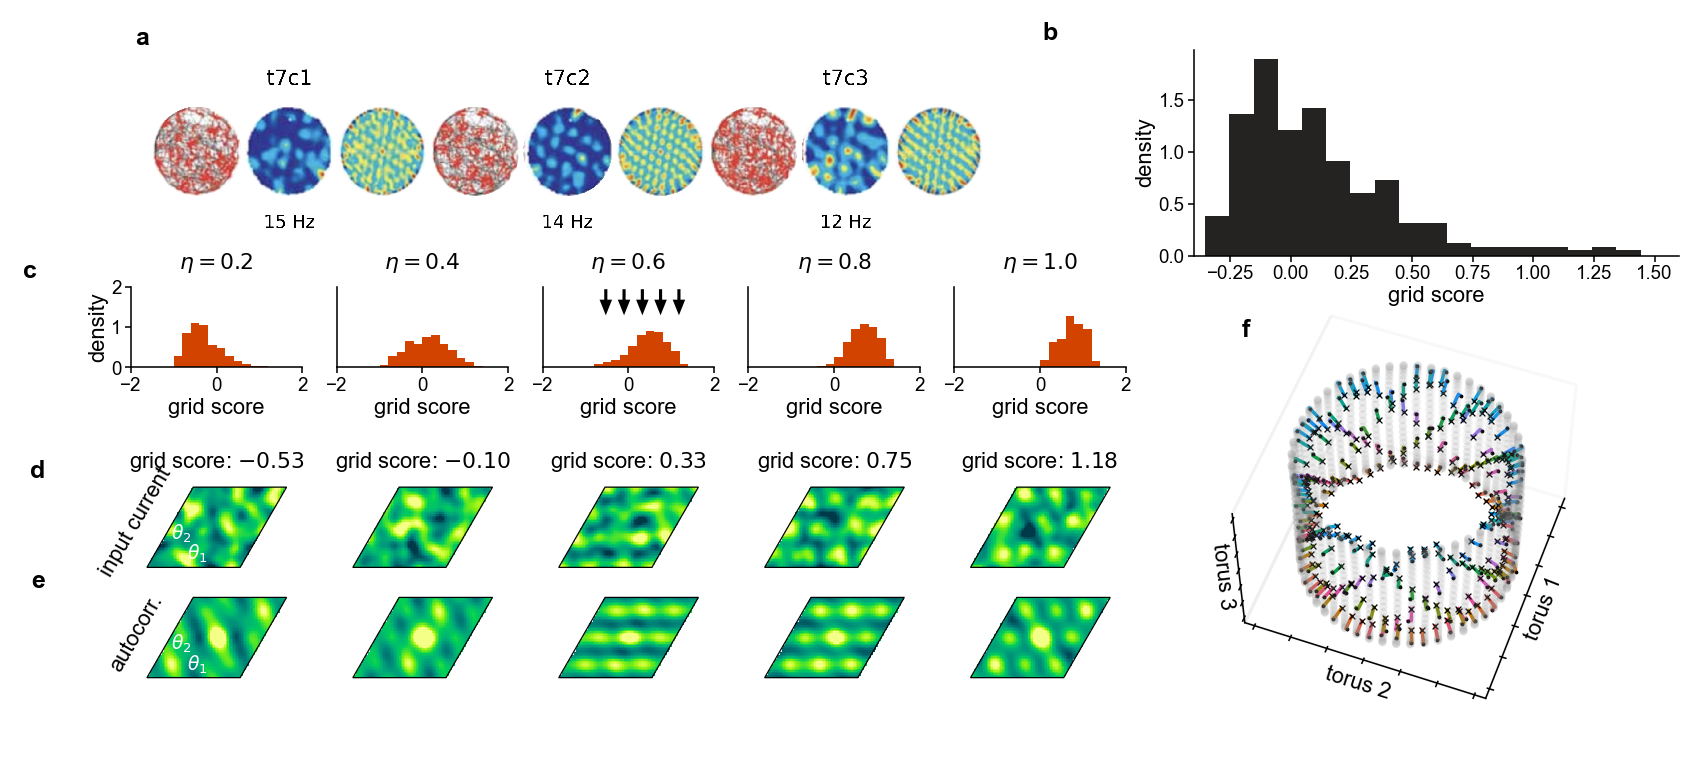

In [6]:
"""
Compose Fig. 8 in full: experimental grid cells vs. the disordered-circuit model.

The whole figure is built from code in one cell. The bottom band (C-F) reuses the same drawing
functions and caches as the grid_cell_panels.svg cell above (plot_patterns_subplot
reads ../data/eta_analysis.npz, plot_3d_torus reads
../data/grid_analysis_results.npz); only the arrangement changes, nesting that
layout under a master gridspec with a top band added above it:
  A  three triplets of experimental grid-cell rate maps (Hafting et al. 2005)
  B  histogram of experimental gridness scores (Nayebi/Mallory)
  C  gridness distributions across eta = 0.2 ... 1.0   (plot_patterns_subplot)
  D  example rate maps at eta = 0.6                    (plot_patterns_subplot)
  E  their rotational autocorrelations                (plot_patterns_subplot)
  F  3D PCA of the toroidal attractor                 (plot_3d_torus)

Panels A and B are borrowed external inputs, not model output, so they load from
committed files rather than from a simulation:
  A  ../figures/external/hafting2005_grid_ratemaps.png
  B  ../data/experimental_gridness_scores.npy
A is the reproduced Hafting-2005 composite (built by
figures/external/composite_hafting_panelA.py from the source screenshot); B is the
digitized Nayebi/Mallory grid-score array. Both are the real assets, so this cell
reproduces the published panels rather than placeholders.

The bottom-band content is stable up to the seeded RNG realization. Panel letters a-f
and the theta1/theta2 axis gizmo on the first rate map are drawn here.
"""

from matplotlib.gridspec import GridSpecFromSubplotSpec

fig = plt.figure(figsize=(style.FULL_W, 3.2))  # slightly less tall than style.TALL_H to remove dead space below panel F

# Master layout: thin top band (borrowed experimental panels) above the tall
# bottom band (the grid_cell_panels.svg layout, reproduced under outer[1]).
outer = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.95],
                         hspace=0.18, left=0.045, right=1.0, top=0.94, bottom=0.02)

# --- TOP band: A (experimental rate maps) | B (experimental gridness scores) ---
top = GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0],
                              width_ratios=[1.8, 1], wspace=0.28)

ax_A = fig.add_subplot(top[0, 0])
img_A = plt.imread('../figures/external/hafting2005_grid_ratemaps.png')
ax_A.imshow(img_A, aspect='equal')  # photo composite: keep circles round (style sets image.aspect='auto')
ax_A.axis('off')

ax_B = fig.add_subplot(top[0, 1])
# Draw the digitized Nayebi Fig 3A bar heights EXACTLY (no resampling), normalized
# as a density so panel B matches panel C's density=True convention.
_gd = np.load('../data/gridness_hist_digitized.npz')
_gw = np.diff(_gd['bin_edges'])
ax_B.bar(_gd['bin_centers'], _gd['density'] / _gw, width=_gw,
         color=style.DATA, align='center', edgecolor='none')
ax_B.set_xlim(-0.4, 1.6)
ax_B.set_xlabel('grid score')
ax_B.set_ylabel('density')

# --- BOTTOM band: nest the create_composite_figure layout under outer[1] ---
bot = GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1],
                              width_ratios=[1.8, 1], wspace=0.0)
ax_3d = fig.add_subplot(bot[0, 1], projection='3d')
plot_3d_torus(ax_3d)

gs_left = GridSpecFromSubplotSpec(6, 5, subplot_spec=bot[0, 0],
                                  height_ratios=[1, 1.05, 1, 0.22, 1, 0.35], hspace=0.1)
# rows 1 and 3 are empty spacers and row 5 is a bottom spacer. Row 3 opens a gap
# between the rate maps (D) and their autocorrelations (E), which read as two
# separate rows and were nearly touching. Row 5 lifts the C/D/E stack so its
# bottom edge lines up with the torus (panel F).
hist_axes = [fig.add_subplot(gs_left[0, i]) for i in range(5)]
pattern_axes = [fig.add_subplot(gs_left[2, i]) for i in range(5)]
corr_axes = [fig.add_subplot(gs_left[4, i]) for i in range(5)]
plot_patterns_subplot(hist_axes, pattern_axes, corr_axes, hist_color=style.MODEL)

# Lift the gridness histograms (panel C) as a rigid row. The mosaic left a wide
# band of dead space under panel A, while C's x-axis labels crowded the
# 'gridness: ...' titles of panel D directly below. Moving C up closes the first
# gap and opens the second in one move; D, E and F do not move.
_C_LIFT = 0.032
for _ax in hist_axes:
    _p = _ax.get_position()
    _ax.set_position([_p.x0, _p.y0 + _C_LIFT, _p.width, _p.height])

# --- theta1/theta2 axis labels, on the first rate map and the first
#     autocorrelogram. White reads more clearly than black over the saturated
#     centre of GRID_CELL_CMAP. Placed just inside the lattice edges: theta_1
#     just inside the bottom (horizontal) edge, theta_2 just inside the left
#     (60 deg) edge. Data coords, so set_aspect(1) keeps them on the map. ---
for _lab_ax in (pattern_axes[0], corr_axes[0]):
    _x0, _x1 = _lab_ax.get_xlim()
    _y0, _y1 = _lab_ax.get_ylim()
    _W, _H = _x1 - _x0, _y1 - _y0
    _PAD = 0.025                      # inset from the lattice edge
    _lab_ax.text(_x0 + 0.36 * _W, _y0 + _PAD * _H, r"$\theta_1$", color="white",
                 size=6, ha="center", va="bottom")
    # the left (60 deg) edge at height y sits at x = x0 + (y - y0)/tan(60 deg);
    # solving on the edge puts the label as far left as it can go.
    _y2 = _y0 + 0.42 * _H
    _lab_ax.text(_x0 + 0.577 * (_y2 - _y0) + _PAD * _W, _y2, r"$\theta_2$",
                 color="white", size=6, ha="left", va="center")

# --- panel letters (a-f) ---
LETTER_KW = dict(fontsize=8, fontweight='bold', va='bottom', ha='right')
ax_A.text(0.0, 1.0, 'a', transform=ax_A.transAxes, **LETTER_KW)
ax_B.text(-0.28, 1.02, 'b', transform=ax_B.transAxes, **LETTER_KW)
hist_axes[0].text(-0.55, 1.05, 'c', transform=hist_axes[0].transAxes, **LETTER_KW)
pattern_axes[0].text(-0.75, 1.05, 'd', transform=pattern_axes[0].transAxes, **LETTER_KW)
corr_axes[0].text(-0.75, 1.05, 'e', transform=corr_axes[0].transAxes, **LETTER_KW)
ax_3d.text2D(0.12, 0.92, 'f', transform=ax_3d.transAxes, **LETTER_KW)

if SAVE_FIGURES:
    plt.savefig("../figures/grid_cell_simulations.pdf", bbox_inches="tight", dpi=450)
plt.show()


## Supplementary Figure S15: eigenvalue spectrum of the toroidal attractor

Re-generates a smaller sample (2,500 maps), fits `J`, and plots the leading real parts of its eigenvalues. The near-degenerate leading cluster is the toroidal analogue of the ring's marginal directions. Because the seed is set at the top of the notebook, this spectrum is only stable for a clean top-to-bottom run. Saves `grid_cell_eigenvalues.pdf`.

In [7]:
X, phi_12, xy, Gamma_x = generate_sample_data(N_samples=2500, radius=0.35, N_phi=50, eta=1., N_period=1)
Phi = nonlin_idealized(X)
J, J_prime = data_driven.compute_weights(X, Phi, lamda=1e-8)

In [8]:
w = np.linalg.eigvals(J)
order = np.argsort(w.real)[::-1]
w = w[order]

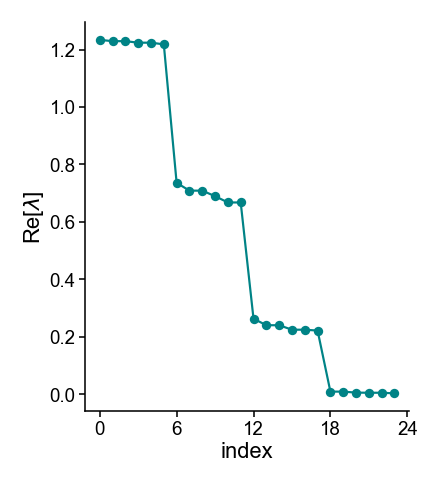

In [9]:
# Small spectrum plot centered on a FULL_W-wide canvas, padded with
# whitespace rather than stretching one small axis edge to edge.
fig = plt.figure(figsize=(style.FULL_W, 2.4))
ax = fig.add_axes([0.40, 0.18, 0.20, 0.72])
ax.plot(np.arange(24), w[:24].real, marker='.', mew=0)
ax.set_xlabel("index")
ax.set_ylabel("Re[$\\lambda$]")
ax.set_xticks([0, 6, 12, 18, 24])
if SAVE_FIGURES:
    plt.savefig("../figures/grid_cell_eigenvalues.pdf")
plt.show()